# Task 4: Perspective Warp (AR Billboard)

Map a quadrilateral in the scene to a flat rectangle (replace with your ad texture).

## Imports & Street Scene

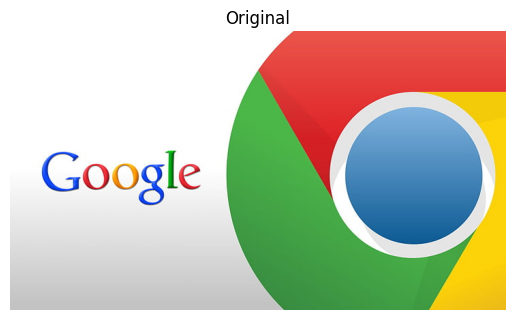

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

street = cv2.imread('../CVLab02/assets/google.jpg')
h, w = street.shape[:2]
ad     = cv2.imread('../CVLab01/assets/buter.jpg')  # 'custom ad'

plt.imshow(cv2.cvtColor(street, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off'); plt.show()


## Board corners -> flat rectangle

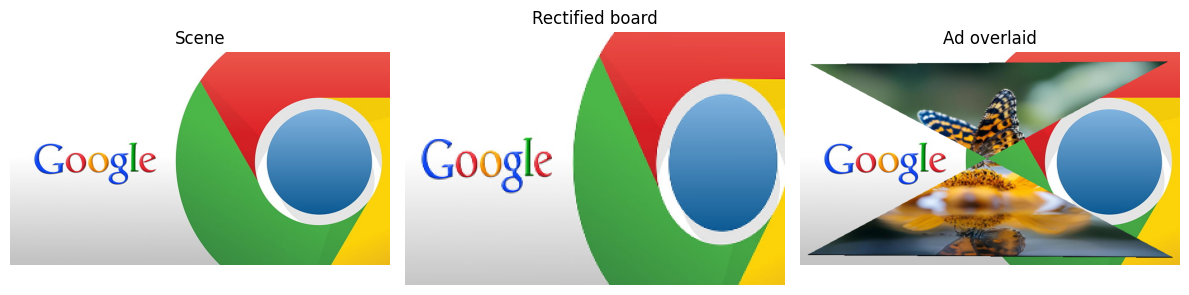

In [3]:
# Source: 4 corners of the billboard region (adjust for your image)
pts_src = np.float32([[20, 25], [w - 25, 20], [15, h - 20], [w - 15, h - 15]])
W_OUT, H_OUT = 300, 200
pts_dst = np.float32([[0, 0], [W_OUT, 0], [0, H_OUT], [W_OUT, H_OUT]])

H_board = cv2.getPerspectiveTransform(pts_src, pts_dst)
flat_board = cv2.warpPerspective(street, H_board, (W_OUT, H_OUT))

ad_rs = cv2.resize(ad, (W_OUT, H_OUT))
# Inverse map: paste flat ad back into perspective
H_inv = np.linalg.inv(H_board)
warped_ad = cv2.warpPerspective(ad_rs, H_inv, (w, h))
mask      = np.zeros((h, w), dtype=np.uint8)
cv2.fillConvexPoly(mask, pts_src.astype(int), 255)
mask_3 = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR) / 255.0
out    = (street * (1 - mask_3) + warped_ad * mask_3).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].imshow(cv2.cvtColor(street, cv2.COLOR_BGR2RGB));       ax[0].set_title('Scene'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(flat_board, cv2.COLOR_BGR2RGB)); ax[1].set_title('Rectified board'); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB));         ax[2].set_title('Ad overlaid'); ax[2].axis('off')
plt.tight_layout(); plt.show()
